In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math 

import networkx as nx

from coppeliasim_zmqremoteapi_client import RemoteAPIClient 

def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])

### HokuyoSensorSim

In [41]:
class HokuyoSensorSim(object):
    _sim = None
    _base_name = ""
    _vision_sensor_name_template = "{}/fastHokuyo_sensor{}"
    _base_obj = None
    _is_range_data = False
    
    _angle_min = -120*math.pi/180
    _angle_max = 120*math.pi/180
    _angle_increment = (240/684)*math.pi/180  # angle: 240 deg, pts: 684

    def __init__(self, sim, base_name, is_range_data=True):
        self._sim = sim
        self._base_name = base_name
        self._is_range_data = is_range_data

        if "fastHokuyo" not in base_name:
            raise ValueError("ERR: fastHokuyo must be in the base object name.")

        self._base_obj = sim.getObject(base_name)
        if self._base_obj == -1:
            raise ValueError("ERR: base_obj is not a valid name in the simulation")

        self._vision_sensors_obj = [
            sim.getObject(self._vision_sensor_name_template.format(self._base_name, 1)),
            sim.getObject(self._vision_sensor_name_template.format(self._base_name, 2)),
        ]

        if any(obj == -1 for obj in self._vision_sensors_obj):
            raise ValueError("ERR: the vision sensors are not valid in the simulation")

    def getSensorData(self):
        angle = self._angle_min
        sensor_data = []
        
        for vision_sensor in self._vision_sensors_obj:
            _, _, u = sim.readVisionSensor(vision_sensor)
            if u:
                
                    for j in range(int(u[1])):
                        for k in range(int(u[0])):
                            w = 2 + 4 * (j * int(u[0]) + k)
                            v = [u[w], u[w + 1], u[w + 2], u[w + 3]]
                            angle = angle + self._angle_increment
                            if self._is_range_data:
                                sensor_data.append([angle, v[3]])
                            else:
                                sensor_data.append([v[0], v[1], v[2]])
                            
        return np.array(sensor_data)


def transform_laser_to_global(laser_data, robot_pos, robot_ori):

    x_r, y_r = robot_pos[0], robot_pos[1]
    theta_r = robot_ori[2]  # orientação em torno de z

    global_points = []

    

    for ang, dist in laser_data:
        if dist > 0.01 and dist < 5:
            # coordenadas no robô
            x_local = dist * np.cos(ang)
            y_local = dist * np.sin(ang)

            # transformação para global
            x_global = x_r + x_local*np.cos(theta_r) - y_local*np.sin(theta_r)
            y_global = y_r + x_local*np.sin(theta_r) + y_local*np.cos(theta_r)

            global_points.append([x_global, y_global])

    return global_points

## Bug algortimo

### Campos Potenciais

In [ ]:
# verificar funcao
def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = ((x_px - img_size/2) * scale)
        y_world = (-(y_px - img_size/2) * scale) 
        return x_world, y_world


In [106]:
def att_force(q, goal, katt=.01):
    return katt*(goal - q)

def rep_force(q, laser_data, R=3, krep=.1):
    # Se lista estiver vazia
    if not laser_data:
        return np.zeros(2)

    laser_data = np.array(laser_data, dtype=float)

    # Garante que tenha 3 colunas (x, y, r)
    if laser_data.shape[1] == 2:
        # adiciona uma coluna de zeros (raio)
        laser_data = np.hstack([laser_data, np.zeros((laser_data.shape[0], 1))])

    # Vetor posição relativa robô -> obstáculo
    v = q - laser_data[:, :2]

    # Distância ao obstáculo (menos o raio)
    d = np.linalg.norm(v, axis=1) - laser_data[:, 2]
    d = np.maximum(d, 1e-6)  # evita divisão por zero
    d = d.reshape(-1, 1)

    # Força repulsiva
    rep = (1/d**2) * ((1/d) - (1/R)) * (v/d)

    # Zera onde fora do raio de influência
    rep[d.flatten() > R, :] = 0.0

    # Retorna soma das forças
    return krep * np.sum(rep, axis=0)

In [ ]:
print('Program started')

# Incia simulacao
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)


# constantes -> verificar
K_att = 50
REP_RADIUS = 0.8
REP_GAIN = 10




ATT_GAIN = 1.0
REP_GAIN = 80.0
REP_RADIUS = 0.8
MAX_REP_FORCE = 25.0

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

GOAL_TOL = 0.20

prev_v_cmd = 0.0
v_smoothing = 0.12

#Configuracao do kobuki
L = 0.230  # distancia do centro as rodas (m) (sugerido no pdf)
r = 0.035  # raio das rodas (m) (sugerido no pdf)

robotname = "kobuki"

robotHandle = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')



sim.startSimulation()
sim.step()

# Conectando a sensor
hokuyo_sensor = HokuyoSensorSim(sim, "/kobuki/fastHokuyo")

# funcoes a verificar
world = pixel_to_world(70,54,100,10)
goal_position = np.array([world[0], world[1]])


while True:
    sim_time = sim.getSimulationTime()

    # Pega as posicoes do robo no mapa
    posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
    oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
    robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

    # verifica se o robo chegou no objetivo e finaliza o loop
    if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
        print("Objetivo alcancado.")
        break

    laser_data = hokuyo_sensor.getSensorData()

    # possiveis calsas de erro
    # nao tem o extend
    laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)

    # onde tudo acontece, verificar no jupyter do professor
    f_att = att_force(robot_pos, goal_position,K_att)
    f_rep = rep_force(robot_pos, laser_global, R = REP_RADIUS, krep = REP_GAIN)

    f_total = f_att + f_rep

    # CONTROLADOR DESAI ET AL. (1998) -> verificar se realmente está correto
    xd, yd = f_total
    theta = oriRobo[2]
    d = L / 2.0  

    J = np.array([
        [np.cos(theta), np.sin(theta)],
        [-np.sin(theta) / d, np.cos(theta) / d]
    ])

    v_cmd, w_cmd = J @ np.array([xd, yd])

    v_cmd *= LINEAR_GAIN
    w_cmd *= ANGULAR_GAIN

    theta_d = np.arctan2(f_total[1], f_total[0])
    erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
    if abs(erro_theta) > np.deg2rad(45):
        v_cmd *= 0.25

    v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
    w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

    prev_v_cmd = v_cmd

    # cinematica diferencial -> olhar no slide para robo diferencial
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    sim.setJointTargetVelocity(l_wheel, v_l)
    sim.setJointTargetVelocity(r_wheel, v_r)

    # print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

    prev_pos = robot_pos.copy()
    sim.step()

sim.stopSimulation()
print('Simulação finalizada.')


Program started


KeyboardInterrupt: 

In [132]:
print('Program started')

# Incia simulacao
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)


# constantes -> verificar
K_att = 50
REP_RADIUS = 0.8
REP_GAIN = 10




ATT_GAIN = 1.0
REP_GAIN = 80.0
REP_RADIUS = 0.8
MAX_REP_FORCE = 25.0

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

GOAL_TOL = 0.20

prev_v_cmd = 0.0
v_smoothing = 0.12

#Configuracao do kobuki
L = 0.230  # distancia do centro as rodas (m) (sugerido no pdf)
r = 0.035  # raio das rodas (m) (sugerido no pdf)

robotname = "kobuki"

robotHandle = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')



sim.startSimulation()
sim.step()





# --- Inicialização ---
hokuyo_sensor = HokuyoSensorSim(sim, "/kobuki/fastHokuyo")
world = pixel_to_world(70, 54, 100, 10)
goal_position = np.array([world[0], world[1]])

mode = "GO_TO_GOAL"
prev_pos = np.zeros(2)
HIT_POINT = None

while True:
    sim_time = sim.getSimulationTime()
    posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
    oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
    robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

    # --- Condição de parada ---
    if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
        print("Objetivo alcançado.")
        break

    # --- Dados do sensor ---
    laser_data = hokuyo_sensor.getSensorData()
    laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)

    # --- Cálculo de forças ---
    f_att = att_force(robot_pos, goal_position, K_att)
    f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN)
    f_total = f_att + f_rep

    # --- Controle de modo Bug2 ---
    dist_to_goal_line = np.abs(np.cross(goal_position - prev_pos, robot_pos - prev_pos) /
                               np.linalg.norm(goal_position - prev_pos))
    min_dist_laser = np.min([np.linalg.norm(p - robot_pos) for p in laser_global])

    if mode == "GO_TO_GOAL":
        # Se há obstáculo muito perto, muda para seguir obstáculo
        if min_dist_laser < 0.5:
            mode = "FOLLOW_OBSTACLE"
            HIT_POINT = robot_pos.copy()
            print(f"Entrando em FOLLOW_OBSTACLE | t={sim_time:.2f}")

    elif mode == "FOLLOW_OBSTACLE":
        # Se voltou à linha para o objetivo e está mais próximo que o ponto de hit
        if dist_to_goal_line < 0.1 and np.linalg.norm(robot_pos - goal_position) < np.linalg.norm(HIT_POINT - goal_position):
            mode = "GO_TO_GOAL"
            print(f"Retornando ao GO_TO_GOAL | t={sim_time:.2f}")

        # Reforço: força repulsiva domina, move contornando obstáculo
        f_total = f_rep + 0.2 * f_att  # pequena atração ainda

    # --- Controle diferencial ---
    xd, yd = f_total
    theta = oriRobo[2]
    d = L / 2.0
    J = np.array([
        [np.cos(theta), np.sin(theta)],
        [-np.sin(theta) / d, np.cos(theta) / d]
    ])

    v_cmd, w_cmd = J @ np.array([xd, yd])
    v_cmd *= LINEAR_GAIN
    w_cmd *= ANGULAR_GAIN

    # Ajuste para ângulo de direção
    theta_d = np.arctan2(f_total[1], f_total[0])
    erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
    if abs(erro_theta) > np.deg2rad(45):
        v_cmd *= 0.25

    v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
    w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

    # Cinemática diferencial
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    sim.setJointTargetVelocity(l_wheel, v_l)
    sim.setJointTargetVelocity(r_wheel, v_r)

    prev_pos = robot_pos.copy()
    sim.step()

sim.stopSimulation()
print('Simulação finalizada.')


Program started


/tmp/ipykernel_45304/1373973892.py:82: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist_to_goal_line = np.abs(np.cross(goal_position - prev_pos, robot_pos - prev_pos) /


Entrando em FOLLOW_OBSTACLE | t=12.55
Retornando ao GO_TO_GOAL | t=15.35
Entrando em FOLLOW_OBSTACLE | t=15.40
Retornando ao GO_TO_GOAL | t=15.45
Entrando em FOLLOW_OBSTACLE | t=15.50
Retornando ao GO_TO_GOAL | t=16.35
Entrando em FOLLOW_OBSTACLE | t=16.40
Retornando ao GO_TO_GOAL | t=16.45
Entrando em FOLLOW_OBSTACLE | t=16.50
Retornando ao GO_TO_GOAL | t=19.30


ValueError: zero-size array to reduction operation minimum which has no identity

In [133]:
import numpy as np

# ======= CONFIGURAÇÕES =======
DIST_OBST = 0.5     # distância mínima para considerar obstáculo (m)
KP_GOAL = 0.5       # ganho proporcional para controle de direção
WALL_FOLLOW_DIST = 0.4  # distância desejada da parede
TOL_GOAL = 0.2      # tolerância para atingir o alvo (m)

# ======= ESTADOS =======
GO_TO_GOAL = 0
FOLLOW_WALL = 1

# ======= FUNÇÕES =======
def angle_to_goal(q, goal):
    """Retorna o ângulo entre o robô e o objetivo"""
    dx, dy = goal[0] - q[0], goal[1] - q[1]
    return np.arctan2(dy, dx)

def laser_front(laser):
    """Média dos valores frontais do laser"""
    n = len(laser)
    return np.mean(laser[n//2 - 5 : n//2 + 5])

def laser_left(laser):
    """Média dos valores à esquerda"""
    n = len(laser)
    return np.mean(laser[int(0.75*n):n])

def laser_right(laser):
    """Média dos valores à direita"""
    n = len(laser)
    return np.mean(laser[:int(0.25*n)])

def bug2(q, theta, goal, laser):
    """
    Retorna velocidade linear e angular
    q: posição (x, y)
    theta: orientação (rad)
    goal: posição alvo (x, y)
    laser: array com distâncias do sensor laser
    """
    global state
    v = 0.0
    w = 0.0

    # Verifica se chegou ao alvo
    dist_to_goal = np.linalg.norm(goal - q)
    if dist_to_goal < TOL_GOAL:
        return 0, 0

    # Leituras do laser
    front = laser_front(laser)
    left = laser_left(laser)
    right = laser_right(laser)

    # ======= MODO GO TO GOAL =======
    if state == GO_TO_GOAL:
        desired = angle_to_goal(q, goal)
        error_angle = np.arctan2(np.sin(desired - theta), np.cos(desired - theta))

        v = 0.2
        w = KP_GOAL * error_angle

        # Se obstáculo à frente, muda para seguir parede
        if front < DIST_OBST:
            state = FOLLOW_WALL

    # ======= MODO FOLLOW WALL =======
    elif state == FOLLOW_WALL:
        v = 0.15
        error = WALL_FOLLOW_DIST - right  # seguir parede à direita
        w = 1.0 * error

        # Se linha até o alvo está livre, volta para GO_TO_GOAL
        desired = angle_to_goal(q, goal)
        error_angle = np.arctan2(np.sin(desired - theta), np.cos(desired - theta))
        if abs(error_angle) < 0.1 and front > 0.8:
            state = GO_TO_GOAL

    return v, w

# ======= LOOP PRINCIPAL (EXEMPLO) =======
if __name__ == "__main__":
    # posição inicial e alvo
    q = np.array([0.0, 0.0])
    theta = 0.0
    goal = np.array([5.0, 3.0])
    state = GO_TO_GOAL

    # simulação (exemplo com dados fake)
    for step in range(100):
        # laser simulado: 180 medidas de 0° a 180°
        laser = np.random.uniform(0.2, 3.0, 180)
        v, w = bug2(q, theta, goal, laser)
        print(f"Step {step}: v={v:.2f}, w={w:.2f}, state={'GOAL' if state==0 else 'WALL'}")

        # atualização simples (modelo cinemático diferencial)
        dt = 0.1
        q[0] += v * np.cos(theta) * dt
        q[1] += v * np.sin(theta) * dt
        theta += w * dt


Step 0: v=0.20, w=0.27, state=GOAL
Step 1: v=0.20, w=0.26, state=GOAL
Step 2: v=0.20, w=0.25, state=GOAL
Step 3: v=0.20, w=0.23, state=GOAL
Step 4: v=0.20, w=0.22, state=GOAL
Step 5: v=0.20, w=0.21, state=GOAL
Step 6: v=0.20, w=0.20, state=GOAL
Step 7: v=0.20, w=0.19, state=GOAL
Step 8: v=0.20, w=0.18, state=GOAL
Step 9: v=0.20, w=0.18, state=GOAL
Step 10: v=0.20, w=0.17, state=GOAL
Step 11: v=0.20, w=0.16, state=GOAL
Step 12: v=0.20, w=0.15, state=GOAL
Step 13: v=0.20, w=0.15, state=GOAL
Step 14: v=0.20, w=0.14, state=GOAL
Step 15: v=0.20, w=0.13, state=GOAL
Step 16: v=0.20, w=0.13, state=GOAL
Step 17: v=0.20, w=0.12, state=GOAL
Step 18: v=0.20, w=0.11, state=GOAL
Step 19: v=0.20, w=0.11, state=GOAL
Step 20: v=0.20, w=0.10, state=GOAL
Step 21: v=0.20, w=0.10, state=GOAL
Step 22: v=0.20, w=0.09, state=GOAL
Step 23: v=0.20, w=0.09, state=GOAL
Step 24: v=0.20, w=0.09, state=GOAL
Step 25: v=0.20, w=0.08, state=GOAL
Step 26: v=0.20, w=0.08, state=GOAL
Step 27: v=0.20, w=0.07, state=GOAL
St

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

WORLDX, WORLDY = 10, 6 

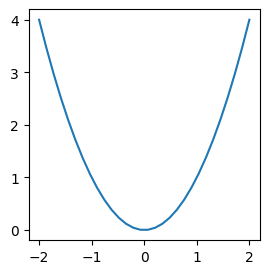

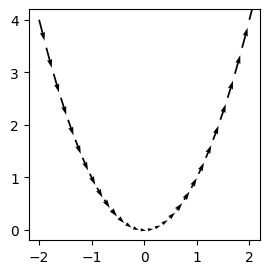

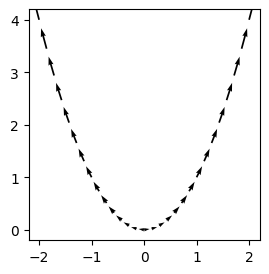

In [55]:
# Atenção com a ordem dos pontos
xn = np.linspace(0, -2, 15)
xp = np.linspace(0, 2, 15)
x =  np.linspace(-2, 2, 30)
y = x**2


fig = plt.figure(figsize=(6,3), dpi=100)
ax = fig.add_subplot(111, aspect='equal')
plt.plot(x, y)



dx = np.gradient(x)
dy = np.gradient(y)

fig = plt.figure(figsize=(6,3), dpi=100)
ax = fig.add_subplot(111, aspect='equal')
ax.quiver(x, y, dx, dy)



fig = plt.figure(figsize=(6,3), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

y = xn**2
dx = np.gradient(xn)
dy = np.gradient(y)
ax.quiver(xn, y, dx, dy)

y = xp**2
dx = np.gradient(xp)
dy = np.gradient(y)
ax.quiver(xp, y, dx, dy)

(0.0, 6.0)

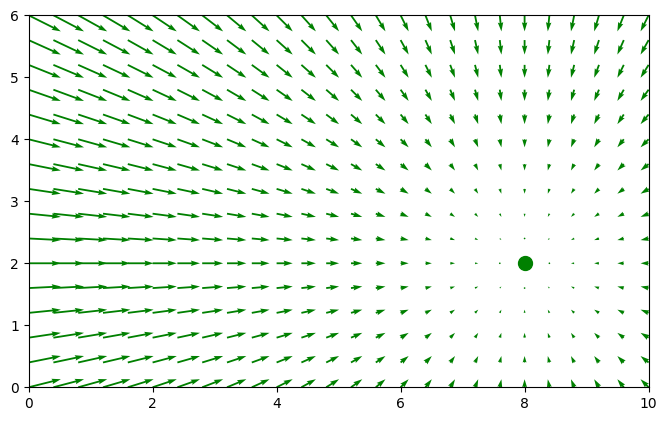

In [56]:
def att_force(q, goal, katt=.01):
    return katt*(goal - q)

goal = np.array([8, 2])

fig = plt.figure(figsize=(8,5), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

XX, YY = np.meshgrid(np.arange(0, WORLDX+.4, .4), np.arange(0, WORLDY+.4, .4))
XY = np.dstack([XX, YY]).reshape(-1, 2)

Fatt = att_force(XY, goal)
Fatt_x = Fatt[:,0]
Fatt_y = Fatt[:,1]

ax.quiver(XX, YY, Fatt_x, Fatt_y, color='g')

plt.plot(goal[0], goal[1], 'og', markersize=10)
    
ax.set_xlim(0, WORLDX)
ax.set_ylim(0, WORLDY)

(0.0, 6.0)

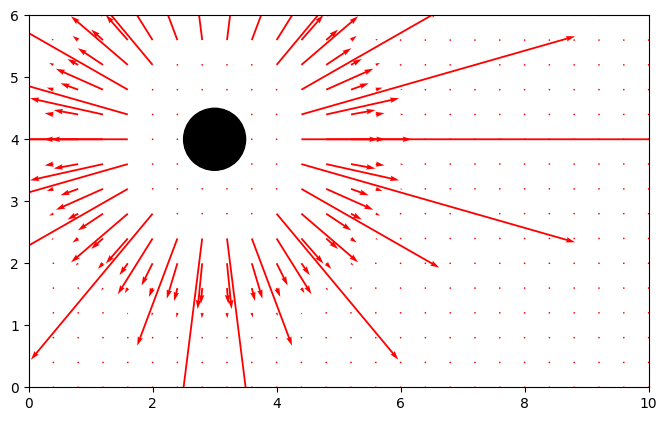

In [ ]:
def rep_force(q, obs, R=3, krep=.1):
    
    # Obstáculo: (x, y, r)
    v = q - obs[0:2]
    d = np.linalg.norm(v, axis=1) - obs[2]
    d = d.reshape((len(v) ,1))
    
    rep = (1/d**2)*((1/d)-(1/R))*(v/d)    
    
    invalid = np.squeeze(d > R)
    rep[invalid, :] = 0
    
    return krep*rep

# Obstáculo: (x, y, r)
laser_data = np.array([3, 4, .5])

fig = plt.figure(figsize=(8,5), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

Frep = rep_force(XY, laser_data)
Frep_x = np.copy(Frep[:,0])  # Cuidado com as referências
Frep_y = np.copy(Frep[:,1])  # Cuidado com as referências

# Threshold para visualização
fmax = .15
Fm = np.linalg.norm(Frep, axis=1)
Frep_x[Fm > fmax], Frep_y[Fm > fmax] = 0, 0

ax.quiver(XX, YY, Frep_x, Frep_y, color='r')
ax.add_patch(patches.Circle((laser_data[0], laser_data[1]), laser_data[2], color='k'))

ax.set_xlim(0, WORLDX)
ax.set_ylim(0, WORLDY)

(0.0, 6.0)

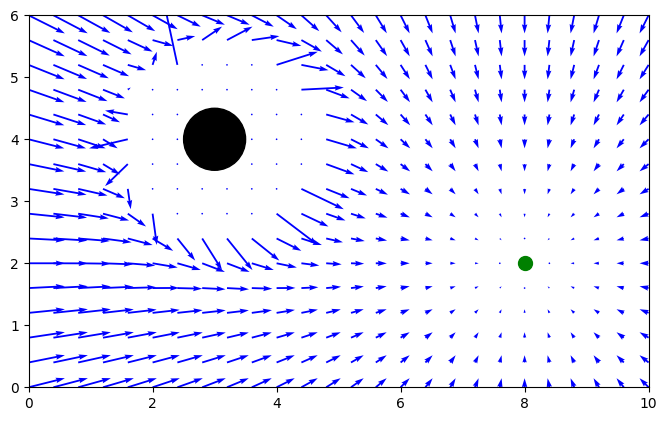

In [ ]:
Ft = Fatt + Frep

# Normalização
# Ft = Ft / np.linalg.norm(Ft, axis=1).reshape((len(Ft), 1))

Ft_x = Ft[:,0]
Ft_y = Ft[:,1]

# Threshold para visualização
fmax = .15
Fm = np.linalg.norm(Ft, axis=1)
Ft_x[Fm > fmax], Ft_y[Fm > fmax] = 0, 0

fig = plt.figure(figsize=(8,5), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

ax.quiver(XX, YY, Ft_x, Ft_y, color='b')
plt.plot(goal[0], goal[1], 'og', markersize=10)
ax.add_patch(patches.Circle((laser_data[0], laser_data[1]), laser_data[2], color='k'))

ax.set_xlim(0, WORLDX)
ax.set_ylim(0, WORLDY)

(0.0, 6.0)

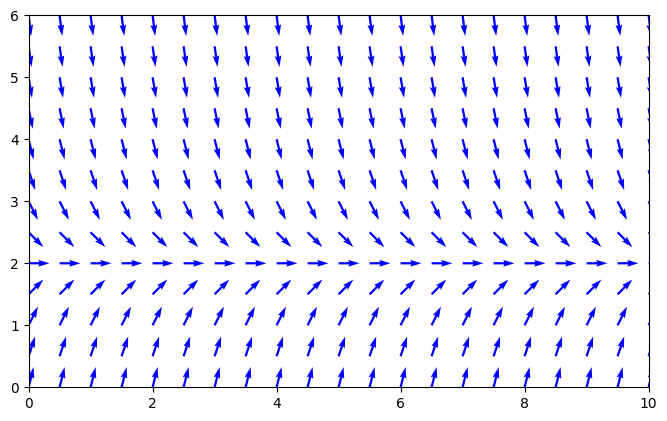

In [59]:
def att_force(q, goal, k=2):
    f = k*(goal - q)
    f[:,0] = 1
    #f[:,1] = 0
    return f

goal = np.array([0, 2])

fig = plt.figure(figsize=(8,5), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

XX, YY = np.meshgrid(np.arange(0, WORLDX+.5, .5), np.arange(0, WORLDY+.5, .5))
XY = np.dstack([XX, YY]).reshape(-1, 2)

Fatt = att_force(XY, goal)
Fatt = Fatt / np.linalg.norm(Fatt, axis=1).reshape((len(Fatt), 1))

Fatt_x = Fatt[:,0]
Fatt_y = Fatt[:,1]

ax.quiver(XX, YY, Fatt_x, Fatt_y, color='b')
    
ax.set_xlim(0, WORLDX)
ax.set_ylim(0, WORLDY)

### Antigo

In [3]:
def rep_force(q, obs_array, R, krep, d_min, max_f_rep):
    if obs_array is None or len(obs_array) == 0:
        return np.zeros(2)

    q = np.asarray(q).reshape(1, -1)
    obs = np.asarray(obs_array).reshape(-1, 2)
    v = q - obs
    d = np.linalg.norm(v, axis=1)
    d_safe = np.maximum(d, d_min)

    within = d < R
    if not np.any(within):
        return np.zeros(2)

    coeff = np.zeros_like(d_safe)
    coeff[within] = krep * ((1.0 / d_safe[within]) - (1.0 / R)) * (1.0 / (d_safe[within] ** 2))
    dirs = v / d_safe.reshape(-1, 1)
    rep = (coeff.reshape(-1, 1) * dirs)
    force_sum = np.sum(rep, axis=0)

    idx_closest = np.argmin(d_safe)
    dir_closest = dirs[idx_closest]
    tangential = np.array([-dir_closest[1], dir_closest[0]])
    tangential_gain = 0.4
    tangential_component = tangential_gain * tangential * min(1.0, np.linalg.norm(force_sum) / (max_f_rep + 1e-6))
    force_sum = force_sum + tangential_component

    norm_f = np.linalg.norm(force_sum)
    if norm_f > max_f_rep:
        force_sum = (force_sum / norm_f) * max_f_rep

    return force_sum


def att_force(q, goal, k, max_f_att):
    f = k * (np.asarray(goal) - np.asarray(q))
    norm = np.linalg.norm(f)
    if norm > max_f_att:
        f = f / norm * max_f_att
    return f

# validacao dos pontos dos sensores
def filter_valid_points(points, robot_pos, min_dist, max_dist):
    if points is None or len(points) == 0:
        return np.empty((0, 2))
    pts = np.asarray(points).reshape(-1, 2)
    d = np.linalg.norm(pts - robot_pos.reshape(1, 2), axis=1)
    mask = np.isfinite(d) & (d > min_dist) & (d < max_dist)
    return pts[mask]


def transform_laser_to_global(laser_points, posRobo_full, oriRobo):
    if laser_points is None or len(laser_points) == 0:
        return np.empty((0, 2))

    x_r, y_r, _ = posRobo_full
    theta = oriRobo[2]

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    pts = np.asarray(laser_points).reshape(-1, 2)
    pts_global = (R @ pts.T).T + np.array([x_r, y_r])
    return pts_global




def escape_if_stuck(robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt):
    stuck_threshold = 0.02
    stuck_time_limit = 1.2
    escape_duration = 2.0
    min_time_between_escapes = 3.0

    moved_dist = np.linalg.norm(robot_pos - prev_pos)
    if moved_dist < stuck_threshold:
        stuck_timer += dt
    else:
        stuck_timer = 0.0

    if (stuck_timer > stuck_time_limit) and (not escape_mode) and ((sim_time - last_escape_time) > min_time_between_escapes):
        escape_mode = True
        last_escape_time = sim_time
        print("[ESCAPE] Robo preso — iniciando rotina de escape")

    if escape_mode:
        if (sim_time - last_escape_time) < escape_duration:
            v = -0.15
            bias = 1.0 if ((int(last_escape_time) % 2) == 0) else -1.0
            w = bias * 0.9
        else:
            escape_mode = False
            v, w = None, None
            stuck_timer = 0.0
    else:
        v, w = None, None

    return v, w, stuck_timer, escape_mode, last_escape_time



def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = ((x_px - img_size/2) * scale)
        y_world = (-(y_px - img_size/2) * scale) 
        return x_world, y_world



In [ ]:
print('Program started')

# constantes
ATT_GAIN = 1.0
REP_GAIN = 80.0
REP_RADIUS = 0.8
MAX_REP_FORCE = 25.0

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

GOAL_TOL = 0.20

prev_v_cmd = 0.0
v_smoothing = 0.12


# simulacao

client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)


#Configuracao robo kobuki

L = 0.230  # distancia do centro as rodas (m)
r = 0.035  # raio das rodas (m)

robotname = "kobuki"

robotHandle = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')

# l_wheel = sim.getObject(f'/{robotname}/kuboki_leftMotor')
# r_wheel = sim.getObject(f'/{robotname}/kuboki_rightMotor')

world = pixel_to_world(89,54,100,10)
goal_position = np.array([world[0], world[1]])


sim.startSimulation()
sim.step()

hokuyo_sensor = HokuyoSensorSim(sim, "/kobuki/fastHokuyo")
has_sensor = True



prev_pos = np.array(sim.getObjectPosition(robotHandle, sim.handle_world)[:2])
stuck_timer = 0.0
escape_mode = False
last_escape_time = -999.0
last_sim_time = sim.getSimulationTime()

while True:
    sim_time = sim.getSimulationTime()
    dt = sim_time - last_sim_time if sim_time - last_sim_time > 0 else 0.05
    last_sim_time = sim_time

    posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
    oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
    robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

    if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
        print("Objetivo alcancado.")
        break

    v_escape, w_escape, stuck_timer, escape_mode, last_escape_time = escape_if_stuck(
        robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt
    )

    if escape_mode and (v_escape is not None):
        v_cmd = v_escape
        w_cmd = w_escape
    else:
        if has_sensor:
            pass
            laser_data = hokuyo_sensor.getSensorData()
            laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
            laser_global = filter_valid_points(laser_global, robot_pos, min_dist=0.05, max_dist= 0.05)
        else:
            laser_global = np.empty((0, 2))

        f_att = att_force(robot_pos, goal_position, k=ATT_GAIN, max_f_att=20.0)
        f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, d_min=0.03, max_f_rep=MAX_REP_FORCE)

        f_total = f_att + f_rep
        if np.linalg.norm(f_total) < 1e-3:
            jitter = 0.05 * (np.random.rand(2) - 0.5)
            f_total = f_total + jitter

    
        # CONTROLADOR DESAI ET AL. (1998)
        xd, yd = f_total
        theta = oriRobo[2]
        d = L / 2.0  

        J = np.array([
            [np.cos(theta), np.sin(theta)],
            [-np.sin(theta) / d, np.cos(theta) / d]
        ])

        v_cmd, w_cmd = J @ np.array([xd, yd])

        v_cmd *= LINEAR_GAIN
        w_cmd *= ANGULAR_GAIN

        theta_d = np.arctan2(f_total[1], f_total[0])
        erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
        if abs(erro_theta) > np.deg2rad(45):
            v_cmd *= 0.25

        v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
        w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

        prev_v_cmd = v_cmd

    # cinematica diferencial
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    sim.setJointTargetVelocity(l_wheel, v_l)
    sim.setJointTargetVelocity(r_wheel, v_r)

    print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

    prev_pos = robot_pos.copy()
    sim.step()

sim.setJointTargetVelocity(l_wheel, 0)
sim.setJointTargetVelocity(r_wheel, 0)



















laser_data = hokuyo_sensor.getSensorData()

print(laser_data)

    
sim.stopSimulation()
print('Simulação finalizada.')

Program started
t=0.05 | pos=[-4.00003551 -4.00000475] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.05
t=0.10 | pos=[-3.99344068 -4.00044135] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.10
t=0.15 | pos=[-3.97411446 -4.00046636] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.15
t=0.20 | pos=[-3.9434876  -4.00050096] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.25 | pos=[-3.90719816 -3.99958634] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.30 | pos=[-3.86770403 -3.99594588] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.35 | pos=[-3.82889943 -3.98926856] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.40 | pos=[-3.79073976 -3.97959461] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.45 | pos=[-3.75326746 -3.96692614] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.50 | pos=[-3.71716873 -3.95155467] | v=0.800, w=-68.0°/s | escape=False | stuck_t=0.00
t=0.55 | pos=[-3.68190513 -3.93396547] | v=0.800, w=-90.0°/s | escape=False | stuck

KeyboardInterrupt: 

In [ ]:

#


In [5]:


# Conexao Coppelia








world = pixel_to_world(89,54,100,10)
goal_position = np.array([world[0], world[1]])



# Informacao do robotino
L = 0.135  # distancia do centro as rodas (m)
r = 0.040  # raio das rodas (m)


# pos_world = {node: pixel_to_world(x_px, y_px, 100, 10) for node, (x_px, y_px) in pos.items()}

# Mdir = np.array([[-r/np.sqrt(3),     0,        r/np.sqrt(3)], 
#                  [r/3,            (-2*r)/3,    r/3], 
#                  [r/(3*L),         r/(3*L),    r/(3*L)]])


# # Posicao inicial do robo - o mesmo da caminho
# start_node = path[0]
# start_pos_world = pos_world[start_node]
# start_pos_sim = [start_pos_world[0], start_pos_world[1], 0.08]
# start_ori_sim = [0, 0, np.deg2rad(90)]




# # Parar a simulacao se estiver executando
# initial_sim_state = sim.getSimulationState()
# if initial_sim_state != 0:
#     sim.stopSimulation()
#     time.sleep(1)

# sim.startSimulation()
# sim.setObjectPosition(robotHandle, sim.handle_world, start_pos_sim)
# sim.setObjectOrientation(robotHandle, sim.handle_world, start_ori_sim)
# sim.step()





# sim.setStepping(True)
# sim.stopSimulation()
# time.sleep(0.5)




# L = 0.381
# r = 0.0975


# hokuyo_sensor = HokuyoSensorSim(sim, "/PioneerP3DX/fastHokuyo")
# has_sensor = True


# sim.startSimulation()

# prev_pos = np.array(sim.getObjectPosition(robotHandle, sim.handle_world)[:2])
# stuck_timer = 0.0
# escape_mode = False
# last_escape_time = -999.0
# last_sim_time = sim.getSimulationTime()

# while True:
#     sim_time = sim.getSimulationTime()
#     dt = sim_time - last_sim_time if sim_time - last_sim_time > 0 else 0.05
#     last_sim_time = sim_time

#     posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
#     oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
#     robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

#     if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
#         print("Objetivo alcancado.")
#         break

#     v_escape, w_escape, stuck_timer, escape_mode, last_escape_time = escape_if_stuck(
#         robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt
#     )

#     if escape_mode and (v_escape is not None):
#         v_cmd = v_escape
#         w_cmd = w_escape
#     else:
#         if has_sensor:
#             laser_data = hokuyo_sensor.getSensorData()
#             laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
#             laser_global = filter_valid_points(laser_global, robot_pos, min_dist=0.05, max_dist= 0.05)
#         else:
#             laser_global = np.empty((0, 2))

#         f_att = att_force(robot_pos, goal_position, k=ATT_GAIN, max_f_att=20.0)
#         f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, d_min=0.03, max_f_rep=MAX_REP_FORCE)

#         f_total = f_att + f_rep
#         if np.linalg.norm(f_total) < 1e-3:
#             jitter = 0.05 * (np.random.rand(2) - 0.5)
#             f_total = f_total + jitter

    
#         # CONTROLADOR DESAI ET AL. (1998)
#         xd, yd = f_total
#         theta = oriRobo[2]
#         d = L / 2.0  

#         J = np.array([
#             [np.cos(theta), np.sin(theta)],
#             [-np.sin(theta) / d, np.cos(theta) / d]
#         ])

#         v_cmd, w_cmd = J @ np.array([xd, yd])

#         v_cmd *= LINEAR_GAIN
#         w_cmd *= ANGULAR_GAIN

#         theta_d = np.arctan2(f_total[1], f_total[0])
#         erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
#         if abs(erro_theta) > np.deg2rad(45):
#             v_cmd *= 0.25

#         v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
#         w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

#         prev_v_cmd = v_cmd

#     # cinematica diferencial
#     v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
#     v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

#     sim.setJointTargetVelocity(l_wheel, v_l)
#     sim.setJointTargetVelocity(r_wheel, v_r)

#     print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

#     prev_pos = robot_pos.copy()
#     sim.step()

# sim.setJointTargetVelocity(l_wheel, 0)
# sim.setJointTargetVelocity(r_wheel, 0)

sim.stopSimulation()
print('Simulação finalizada.')
    
    

Program started


NameError: name 'pos' is not defined